# Tag 07 — Fortgeschrittene
## Pruning and Feature Importance — Pima Indians Diabetes

تمرین‌ها:
1. `min_samples_leaf=1,5,10,20` و مقایسه Train/Test Accuracy
2. Cost-Complexity Pruning با `ccp_alpha`
3. Feature Importance به صورت bar chart

In [3]:

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Find project root automatically
PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT.name not in ["Tag_07_Decision_Trees_Project", ""] and not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "raw"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "02_fortgeschrittene"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data dir:", DATA_DIR)
print("Output dir:", OUTPUT_DIR)


Project root: c:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_07_Decision_Trees_Project
Data dir: c:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_07_Decision_Trees_Project\data\raw
Output dir: c:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_07_Decision_Trees_Project\outputs\02_fortgeschrittene


In [4]:

diabetes_path = DATA_DIR / "diabetes.csv"
if not diabetes_path.exists():
    raise FileNotFoundError(f"Could not find {diabetes_path}. Put diabetes.csv into data/raw/.")

df = pd.read_csv(diabetes_path)
print(df.shape)
df.head()


(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:

# Expected target column for Pima dataset is usually Outcome.
target_col = "Outcome" if "Outcome" in df.columns else df.columns[-1]
print("Target column:", target_col)
print("Missing values:\n", df.isna().sum())
print("Target distribution:\n", df[target_col].value_counts(normalize=True).round(3))

X = df.drop(columns=[target_col])
y = df[target_col]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_tr.shape, X_te.shape)


Target column: Outcome
Missing values:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Target distribution:
 Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64
(614, 8) (154, 8)


## 1) min_samples_leaf comparison

In [6]:

leaves = [1, 5, 10, 20]
rows = []
for leaf in leaves:
    model = DecisionTreeClassifier(min_samples_leaf=leaf, random_state=42)
    model.fit(X_tr, y_tr)
    rows.append({
        "min_samples_leaf": leaf,
        "train_accuracy": model.score(X_tr, y_tr),
        "test_accuracy": model.score(X_te, y_te),
        "tree_depth": model.tree_.max_depth,
        "node_count": model.tree_.node_count
    })

leaf_df = pd.DataFrame(rows)
leaf_df.to_csv(OUTPUT_DIR / "intermediate_min_samples_leaf_results.csv", index=False)
leaf_df


,min_samples_leaf,train_accuracy,test_accuracy,tree_depth,node_count
0,1,1.000000,0.727273,16,229
1,5,0.892508,0.746753,12,127
2,10,0.833876,0.753247,9,77
3,20,0.812704,0.772727,7,43


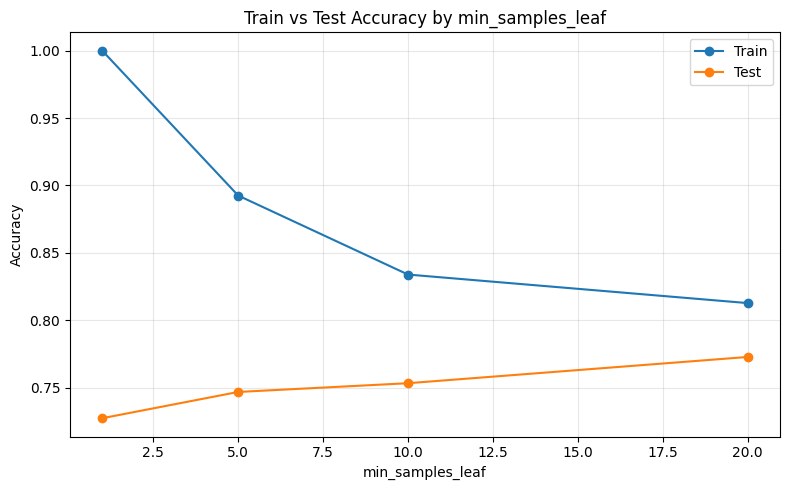

In [7]:

plt.figure(figsize=(8,5))
plt.plot(leaf_df["min_samples_leaf"], leaf_df["train_accuracy"], marker="o", label="Train")
plt.plot(leaf_df["min_samples_leaf"], leaf_df["test_accuracy"], marker="o", label="Test")
plt.xlabel("min_samples_leaf")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy by min_samples_leaf")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "intermediate_min_samples_leaf_accuracy.png", dpi=150)
plt.show()


## 2) Cost-Complexity Pruning

In [8]:
from sklearn.tree import DecisionTreeClassifier

Test Accuracy: 0.7468


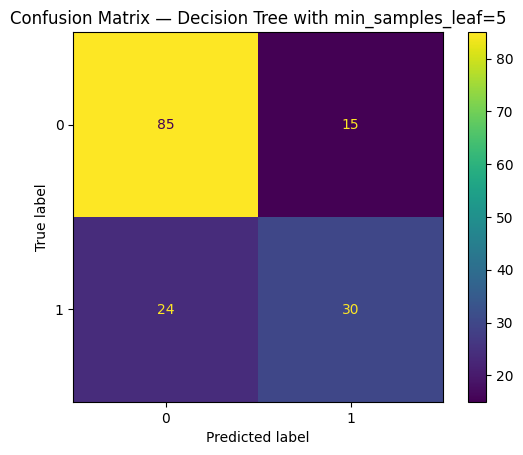

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X_tr = X_tr.reset_index(drop=True)
y_tr = y_tr.reset_index(drop=True)

model = DecisionTreeClassifier(
    min_samples_leaf=5,
    random_state=42
)

model.fit(X_tr, y_tr)

y_pred = model.predict(X_te)

acc = accuracy_score(y_te, y_pred)
print(f"Test Accuracy: {acc:.4f}")

cm = confusion_matrix(y_te, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.title("Confusion Matrix — Decision Tree with min_samples_leaf=5")
plt.show()


In [10]:

base_tree = DecisionTreeClassifier(random_state=42)
path = base_tree.cost_complexity_pruning_path(X_tr, y_tr)
alphas = path.ccp_alphas

# Often the last alpha collapses the tree to root only; keep it but mark it.
rows = []
for alpha in alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(X_tr, y_tr)
    rows.append({
        "ccp_alpha": alpha,
        "train_accuracy": model.score(X_tr, y_tr),
        "test_accuracy": model.score(X_te, y_te),
        "tree_depth": model.tree_.max_depth,
        "node_count": model.tree_.node_count
    })

alpha_df = pd.DataFrame(rows)
alpha_df.to_csv(OUTPUT_DIR / "intermediate_ccp_alpha_results.csv", index=False)
best_row = alpha_df.loc[alpha_df["test_accuracy"].idxmax()]
print("Best alpha row:")
print(best_row)
alpha_df.head()


Best alpha row:
ccp_alpha          0.005776
train_accuracy     0.806189
test_accuracy      0.798701
tree_depth         5.000000
node_count        15.000000
Name: 51, dtype: float64


,ccp_alpha,train_accuracy,test_accuracy,tree_depth,node_count
0,0.000000,1.000000,0.727273,16,229
1,0.001046,0.998371,0.740260,16,223
2,0.001402,0.991857,0.740260,16,205
3,0.001425,0.988599,0.727273,16,197
4,0.001466,0.986971,0.727273,16,193


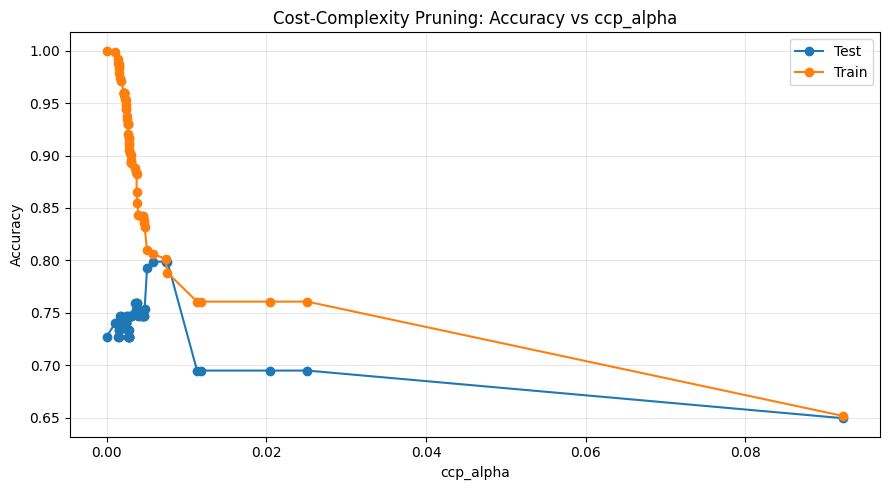

In [11]:

plt.figure(figsize=(9,5))
plt.plot(alpha_df["ccp_alpha"], alpha_df["test_accuracy"], marker="o", label="Test")
plt.plot(alpha_df["ccp_alpha"], alpha_df["train_accuracy"], marker="o", label="Train")
plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("Cost-Complexity Pruning: Accuracy vs ccp_alpha")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "intermediate_ccp_alpha_accuracy.png", dpi=150)
plt.show()


## 3) Feature Importance

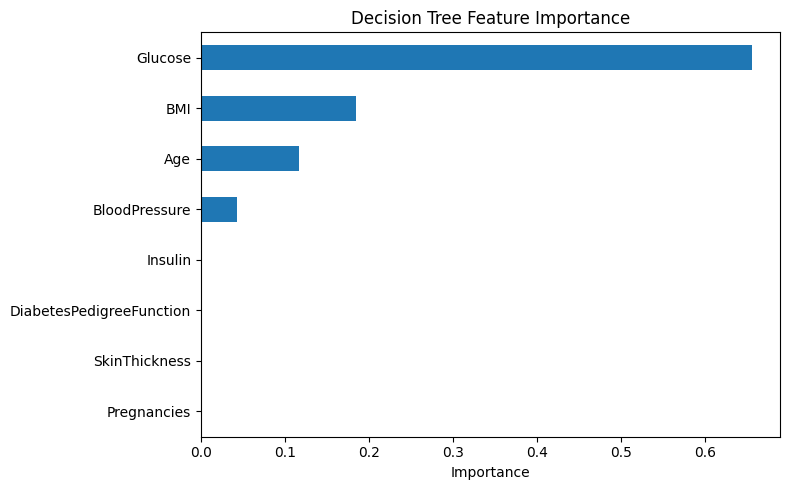

Glucose                     0.655966
BMI                         0.184773
Age                         0.116119
BloodPressure               0.043142
Insulin                     0.000000
DiabetesPedigreeFunction    0.000000
SkinThickness               0.000000
Pregnancies                 0.000000
dtype: float64

In [12]:

best_alpha = float(best_row["ccp_alpha"])
dt_best = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
dt_best.fit(X_tr, y_tr)

fi = pd.Series(dt_best.feature_importances_, index=X.columns).sort_values()
fi.to_csv(OUTPUT_DIR / "intermediate_feature_importances.csv", header=["importance"])

plt.figure(figsize=(8,5))
fi.plot(kind="barh")
plt.xlabel("Importance")
plt.title("Decision Tree Feature Importance")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "intermediate_feature_importance.png", dpi=150)
plt.show()

fi.sort_values(ascending=False)


## What to send back

- `intermediate_min_samples_leaf_results.csv`
- `intermediate_ccp_alpha_results.csv`
- `intermediate_feature_importances.csv`
- plots from `outputs/02_fortgeschrittene/`